# Fitting Example (NLSF & MLE) - Mono-exponential FLI data processing

This example fits a simulated, mono-exponential fluorescence lifetime image (FLI) pixel by pixel with two estimators and compares them against the known ground truth:

- **Non-linear least squares (NLSF)**: minimizes the sum of squared residuals between the IRF-convolved model and the decay. It is fast and works well when photon counts are high, since the noise is then close to Gaussian.
- **Maximum likelihood estimation (MLE)**: maximizes the Poisson log-likelihood of the photon counts. It models the counting statistics directly, so it remains accurate at low photon counts, where least squares becomes biased.

This example walks through:
- Simulating a whole FLI image with known lifetimes (as in the "Whole Image Simulation" example)
- Comparing NLSF and MLE on a single pixel
- Fitting the whole image with NLSF and with MLE
- Comparing the fitted lifetime maps and their distributions with the ground truth
- Inspecting the fit and residuals at individual pixels

<small>Author - Vikas</small>

In [49]:
import sys

import numpy as np

sys.path.insert(0, "ex_helper")  # local helper for synthetic image generation

from sim_general_image import LettersShape, ROIMaskGenerator

from pyfli.analysis.utils import plot_pixel_diagnostic, random_true_pixel
from pyfli.analyticalWorkflow import AnalyticalHelpers
from pyfli.data_cc import Normalization
from pyfli.data_text import MessageDisplay
from pyfli.data_vnp import ColorProcessor, DataViewer, Plotter
from pyfli.io import DataOperations
from pyfli.simulator import FLIModelImageGenerator
from pyfli.solver import (
    BaseFLIFitter,
    BinnedFLIFitter,
    FittingComparator,
    FLICPUProcessor,
    MLEFLIFitter,
)

## Generating a test image

A test image is simulated to compare the ground truth against the estimated values. In this example, a 128 x 512 image is generated with the letters "F", "L", "I", "M". Each letter is assigned a different intensity value (grayscale bit size) and a different lifetime: 0.7 ± 0.05 ns, 0.8 ± 0.05 ns, 0.9 ± 0.05 ns, and 1.0 ± 0.05 ns, respectively.

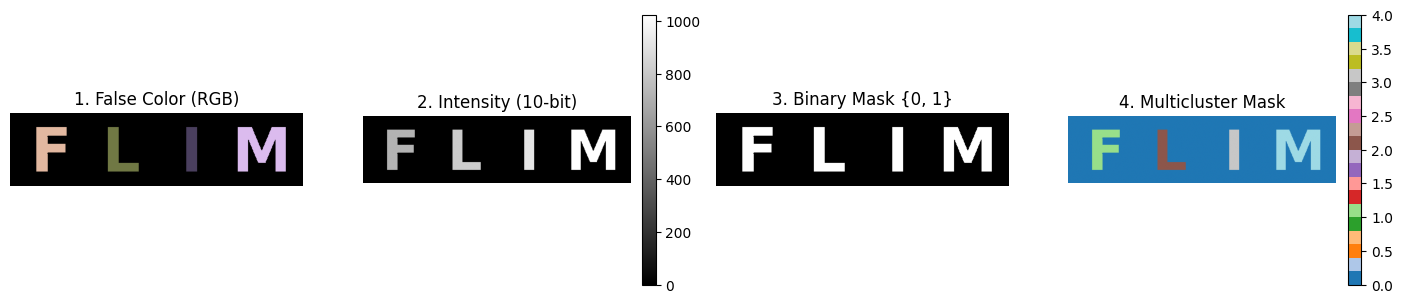

In [50]:
h, w = 128, 512
generator = ROIMaskGenerator((h, w), top=10, bottom=10, left=10, right=10)
FLIM_letters = LettersShape(letters=("F", "L", "I", "M"), gap=0.15)

custom_intensities = [0.7, 0.8, 0.9, 1.0]
# Preview the generated image
_ = generator.plot_preview(
    FLIM_letters,
    bit_depth=10,
    intensities=custom_intensities,
    show=True,
)

## Loading the IRF

The instrument response function (IRF) is convolved with the decay model during both simulation and fitting. Its number of time gates also sets the gate width and the laser/acquisition frequencies used by the fitters.

In [ ]:
# Path to the local IRF file
IRF_PATH = "<select file/folder path>"

In [52]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()

gate_delay = 12.5 / irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(
    laser_period=12.5, gate_delay=gate_delay, num_gate=num_gates
).freq_computation()

INFO:pyfli:Initiating IRF load from: <select file/folder path>


## Simulation configuration

`MODEL_TYPE` selects the decay model for both the simulation and the fits. Setting `mono_fraction` to 1.0 forces every simulated pixel to be mono-exponential.

In [53]:
MODEL_TYPE = "mono-exponential"

# Your constant, default configuration
BASE_CONFIG = {
    # Modular Noise
    "jitter": False,  # offset artifact (due to jitter)
    "dcr_on": True,  # Dark Count Rate (thermal background)
    "poisson": False,  # Shot noise — Large detector only
    "qe_on": True,  # Quantum efficiency scaling
    "read_noise_on": False,  # Gaussian read noise — Large detector only
    # Sensor
    "sensor_type": "discrete",  # "continuous" | "discrete"
    "bit": 12,
    "dcr": 0.08,  # Mean dark counts per bin
    "laser_feq": freq[1],  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on": True,  # Round photon counts to integers — Macro_sim only
    "clip_on": True,  # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count
    # Fluorescence Physics (FLI / FRET)
    "tau2": (1, 1),  # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist": "beta",  # if dist "beta" or "normal" (default)
    "efficiency": (1, 1),  # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction": (1, 1),  # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count": (2, 5),  # Peak intensity ~ Beta(2, 5) × max_adc - large detectors
    "mono_fraction": 1.0,  # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles": (1_500_000, 2_000_000),  # Accumulation cycles — for photon counter
}

Different ROIs (letter areas, in this case) are assigned different lifetimes.

In [54]:
def get_config(**kwargs):
    """Create a config by overriding defaults with specific test parameters."""
    config = BASE_CONFIG.copy()
    config.update(kwargs)
    return config


ROI0 = {}
ROI1 = get_config(
    tau2_beta_range=(0.05, 0.5),
)
ROI2 = get_config(
    tau2_beta_range=(0.05, 0.7),
)
ROI3 = get_config(
    tau2_beta_range=(0.05, 0.9),
)
ROI4 = get_config(
    tau2_beta_range=(0.05, 1.1),
)

In [55]:
img_intensity = generator.generate_intensity_image(
    FLIM_letters, intensities=custom_intensities
)
img_cluster = generator.generate_cluster_mask(FLIM_letters)
b_bool_mask = generator.generate_binary_mask(FLIM_letters)

simulated_img = FLIModelImageGenerator(
    irf_data=irf_data[120, 40, :],
    intensity_image=img_intensity,
    roi_mask=img_cluster,
    roi_params=[ROI0, ROI1, ROI2, ROI3, ROI4],
    method="PHOTON_COUNTER",
    verbose=True,
    bool_mask=b_bool_mask,
)

gt_data = simulated_img.generate_image()

INFO:pyfli:Generating PHOTON_COUNTER FLI Image [128x512x256]...


### Ground-truth maps

The simulator returns the parameter maps used to generate the data. These are the reference values for the fits below.

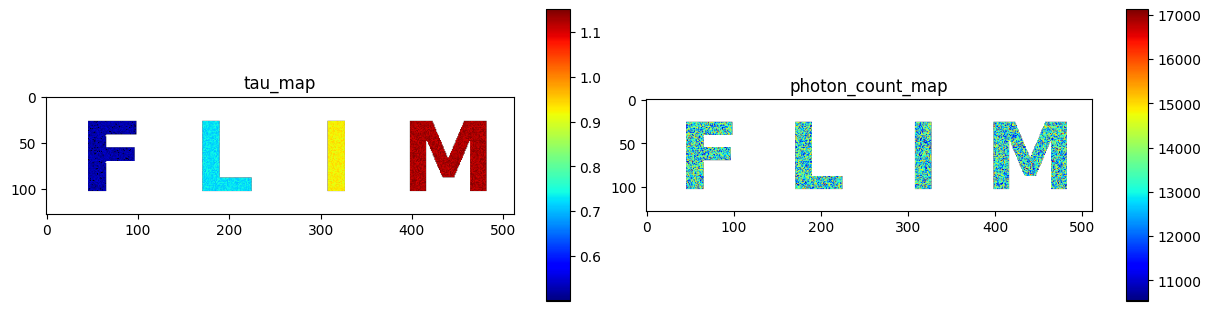

In [56]:
gt_maps = gt_data["results"]["maps"]
jet_m = ColorProcessor().lowest_zero("jet")

_ = DataViewer().display_data(
    [gt_maps["tau_map"], gt_maps["photon_count_map"]],
    structure=(1, 2),
    coord=None,
    data_names=["tau_map", "photon_count_map"],
    cmaps=[jet_m] * 2,
    v_ranges=None,
    figsize=(12, 3),
    normalize=False,
    yscale="linear",
)

Check the decay, IRF, and fit at a randomly selected pixel.

the non-zero pixel selected for probing is (27, 476)


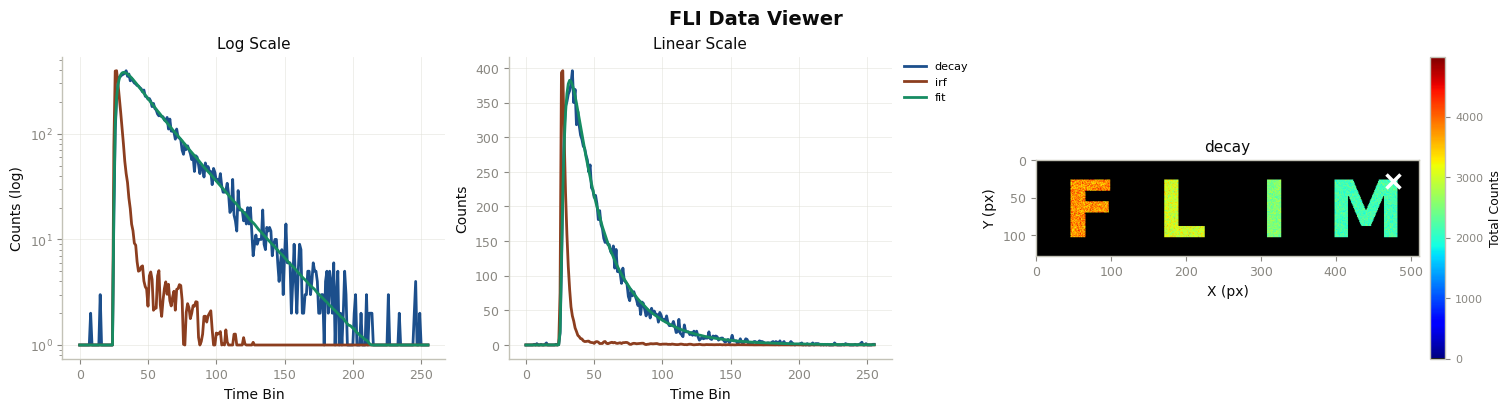

INFO:pyfli:
  Pixel (27, 476)
  ─────────────────────
  A         13376.7197
  α         —
  τ₁        1.1319
  τ₂        —
  R²        —
  Red.χ²    —
  Raw.χ²    —
  v-shift   0.0000
  h-shift   —
  ─────────────────────



In [57]:
_decay = gt_data["raw_data"]["decay"]
_irf = gt_data["raw_data"]["irf"]
x, y = random_true_pixel(b_bool_mask)
TRs = gt_data["results"]["TR_maps"]
print(f"the non-zero pixel selected for probing is ({x}, {y})")
irf_norm = Normalization(_irf).norm_scale(_decay)
DataViewer().plot_fli_px(
    data_list=[_decay, irf_norm, TRs["fit_map"], TRs["residual_map"]],
    pixel=(x, y),
    mode=[0, 1, 2],
    mode2=[1],
    names=["decay", "irf", "fit"],
    cmap=jet_m,
)
_ = MessageDisplay().get_pixel_summary(data_maps=gt_maps, px=(x, y))

## Single-pixel fit: NLSF vs MLE

Before fitting the whole image, `FittingComparator` fits one randomly selected pixel with both estimators and plots the fits side by side:

- `"least_squares"` uses `BaseFLIFitter` (NLSF)
- `"poisson"` uses `MLEFLIFitter` (Poisson MLE)

`p0` (initial guess) and `bounds` are left as `None`, so the fitter derives its own initial guess from the data. For a mono-exponential model the parameters are `[S, tau, v_shift, h_shift]`, and both can be passed in that order.


┌──────────────────────────────────────────────────────────────┐
│  FLI Fitting Results  |  MONO-EXPONENTIAL                    │
│  2 methods queued                                            │
└──────────────────────────────────────────────────────────────┘


┌────────────────┬──────┬─────────┬──────────┬─────────┬──────────┬──────────┬─────────┬──────────┐
│ Method         │ Type │       A │        τ │      R² │   Red.χ² │   Raw.χ² │ v-shift │  h-shift │
├────────────────┼──────┼─────────┼──────────┼─────────┼──────────┼──────────┼─────────┼──────────┤
│ LEAST_SQUARES  │ NLSF │  795.86 │    0.720 │  0.9950 │   1.0449 │   263.32 │    0.00 │   -0.106 │
│ POISSON        │ MLE  │  712.49 │    0.730 │  0.9951 │   0.9548 │   240.60 │    0.25 │   -0.019 │
└────────────────┴──────┴─────────┴──────────┴─────────┴──────────┴──────────┴─────────┴──────────┘



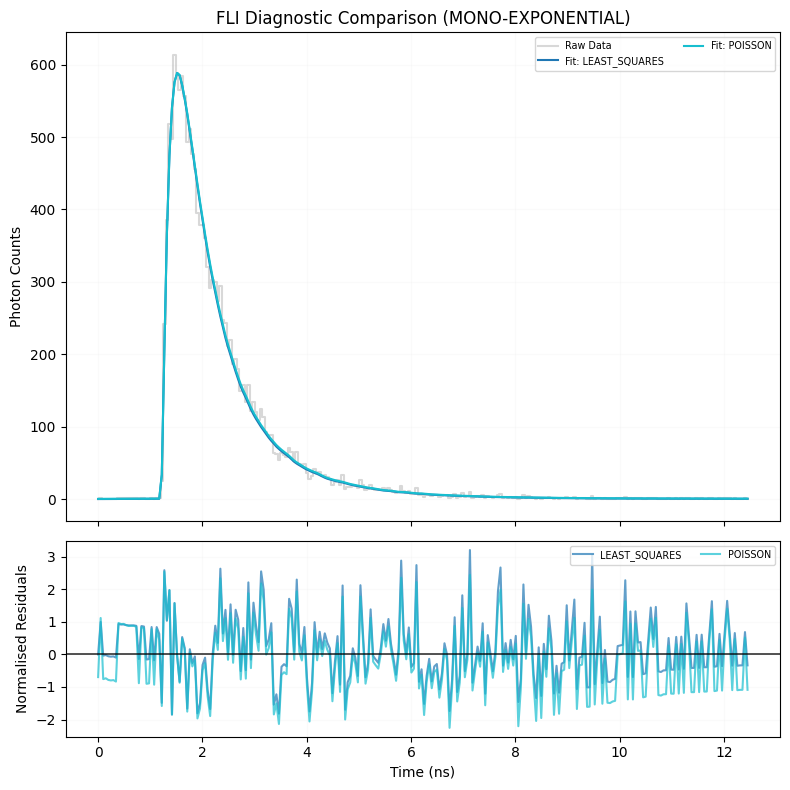

In [58]:
p0 = None
bounds = None

xd, yd = random_true_pixel(b_bool_mask)
pixel_decay = _decay[xd, yd, :]
pixel_irf = _irf[xd, yd, :]

comparator = FittingComparator(freq, BaseFLIFitter, MLEFLIFitter)
comp_results_table, comp_fig = comparator.compare_selected(
    ["least_squares", "poisson"],
    y_data=pixel_decay,
    irf_data=pixel_irf,
    model_type=MODEL_TYPE,
    p0=p0,
    bounds=bounds,
    yscale="linear",
    plot=True,
)

## Whole-image fitting

Each pixel is fitted independently and in parallel on the CPU:

- `FLICPUProcessor(freq, fitter_class)` spreads the per-pixel fits over `n_jobs` worker processes. The fitter class sets the estimator family.
- `BinnedFLIFitter(..., bin_radius=0)` is the image-level entry point. A `bin_radius` of 0 fits every pixel as-is, and a larger radius sums each pixel with its neighbours first to raise the photon count.
- `max_iter` caps the optimizer's function evaluations per pixel.

On a machine with a CUDA GPU, `FLIGPUProcessor` can be used in place of `FLICPUProcessor` to fit all pixels as one batch.

### NLSF

In [59]:
MAX_ITER = 1000
N_JOBS = 7

nlsf_fitter = BinnedFLIFitter(FLICPUProcessor(freq, BaseFLIFitter), bin_radius=0)
results_nlsf = nlsf_fitter.fit(
    b_img=_decay,
    b_irf=_irf,
    estimator="least_squares",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_nlsf",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (least_squares): 100%|██████████| 10241/10241 [00:19<00:00, 522.93px/s]


### MLE

The same pipeline is run with `MLEFLIFitter` and the `"poisson"` estimator. MLE takes longer per pixel than NLSF.

In [60]:
mle_fitter = BinnedFLIFitter(FLICPUProcessor(freq, MLEFLIFitter), bin_radius=0)
results_mle = mle_fitter.fit(
    b_img=_decay,
    b_irf=_irf,
    estimator="poisson",
    model_type=MODEL_TYPE,
    n_jobs=N_JOBS,
    data_name="simulated_mle",
    max_iter=MAX_ITER,
)

INFO:pyfli:Engine: CPU Parallel Processor (via FLICPUProcessor)
Fitting Pixels (poisson): 100%|██████████| 10241/10241 [01:16<00:00, 133.36px/s]


## Comparing the results

Every fit result has the same layout: `results["results"]["maps"]` holds the parameter maps (`tau_map`, `R2_map`, `reduced_chi2_map`, ...), and `results["results"]["TR_maps"]` holds the per-pixel fitted curves (`fit_map`) and residuals (`residual_map`).

### Lifetime maps

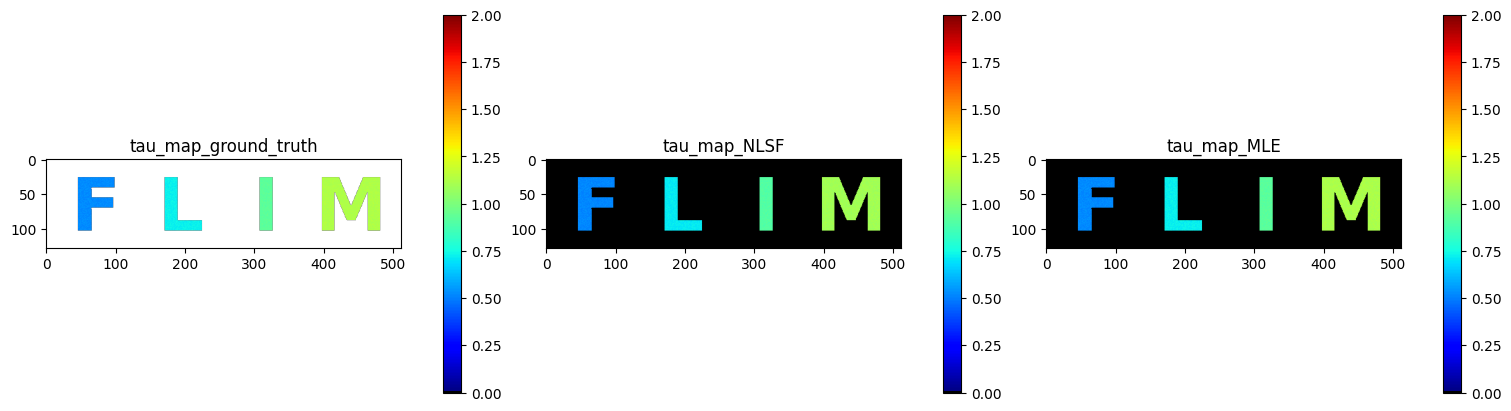

In [61]:
experiments = {"NLSF": results_nlsf, "MLE": results_mle}
all_datasets = [res["results"]["maps"] for res in experiments.values()]
all_fitset = [res["results"]["TR_maps"] for res in experiments.values()]

_ = DataViewer().display_data(
    [gt_maps["tau_map"]] + [maps["tau_map"] for maps in all_datasets],
    structure=(1, 3),
    coord=None,
    data_names=["tau_map_ground_truth"] + [f"tau_map_{name}" for name in experiments],
    cmaps=[jet_m] * 3,
    v_ranges=[(0, 2)] * 3,
    figsize=None,
    normalize=False,
    yscale="linear",
)

### Lifetime distributions

`Plotter` compares the lifetime values of the letter pixels across the sources. The `operations` dict is applied to every source: it keeps only pixels inside the mask, drops failed fits (NaN or zero) and discards values outside the threshold range. A list of dicts, one per source, can be passed instead to filter each source differently.

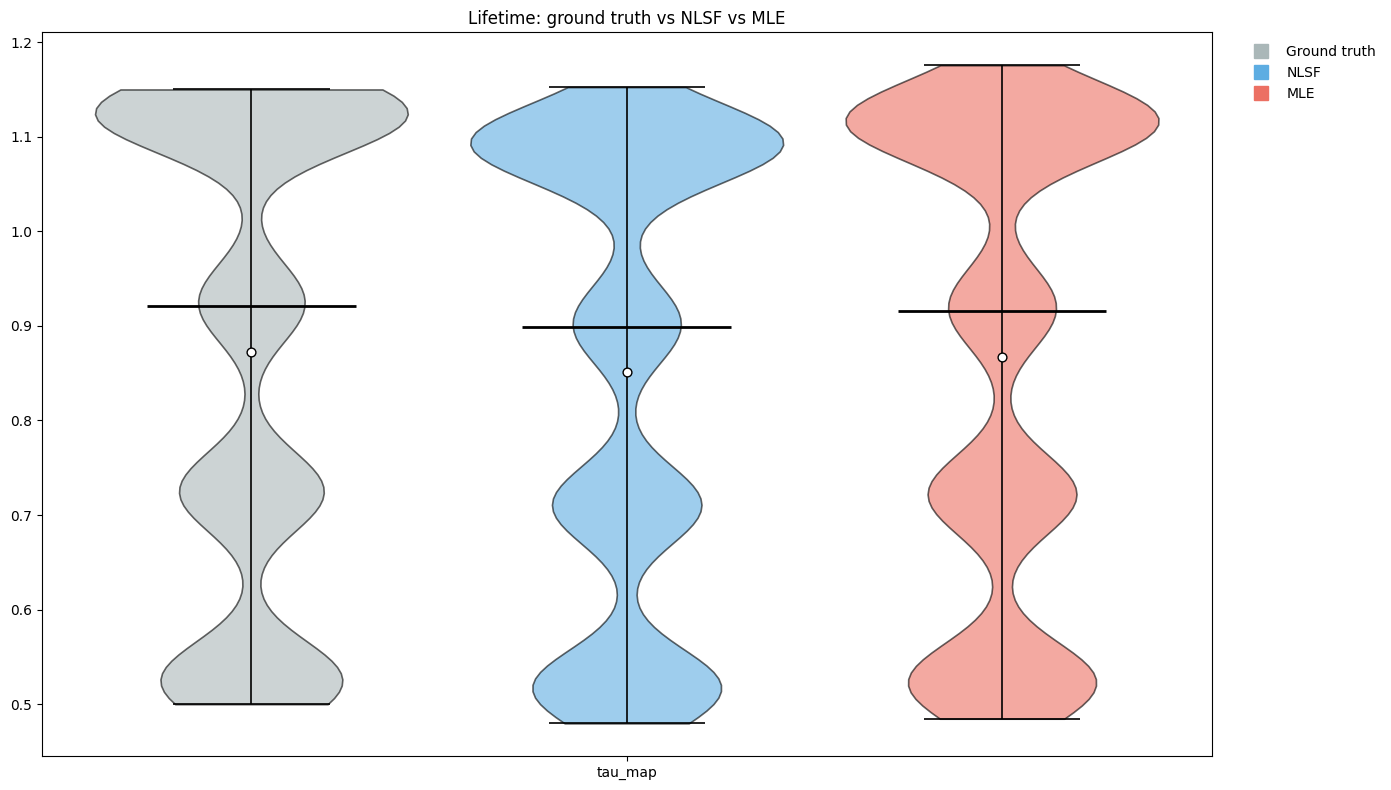

In [62]:
names = ["Ground truth"] + list(experiments)
plotter_ops = {
    "mask": b_bool_mask.ravel(),
    "remove_nan": True,
    "remove_zero": True,
    "threshold": (0, 7),
}

painter = Plotter(
    gt_maps,
    *all_datasets,
    values=["tau_map"],
    style_config=["#AAB7B8", "#5DADE2", "#EC7063"],
    source_names=names,
    operations=plotter_ops,
)

fig = painter.make_plot(
    title="Lifetime: ground truth vs NLSF vs MLE",
    graph_type="violin",
    point_type="strip",
    show_mean=True,
    show_median=True,
    show_significance=True,
    test_type="none",
    correction=False,
)

`graph_type` can also be `"box"`, `"swarm"`, `"overlay"`, `"raincloud"` or `"kde"`. Setting `test_type` to `"paired"` or `"welch"` adds significance tests between the sources.

### Fits at a single pixel

`plot_pixel_diagnostic` overlays the NLSF and MLE fitted curves on the measured decay at one pixel, with the residuals below.

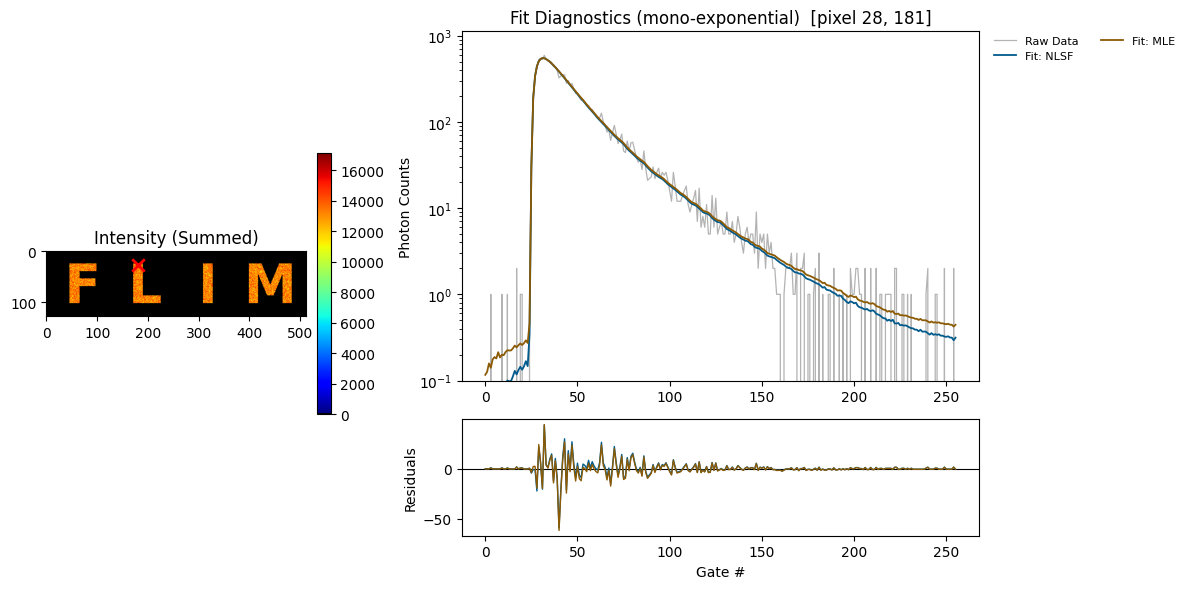

In [63]:
x, y = random_true_pixel(b_bool_mask)
_ = plot_pixel_diagnostic(
    _decay,
    all_fitset,
    list(experiments),
    mask=b_bool_mask,
    pixel=(x, y),
    t=None,
    yscale="log",
    raw_style="line",
    model_type=MODEL_TYPE,
)

The same pixel is shown for each estimator, along with the fitted parameters and goodness-of-fit metrics (R², reduced χ²).

the non-zero pixel selected for probing is (28, 181)
--- NLSF ---


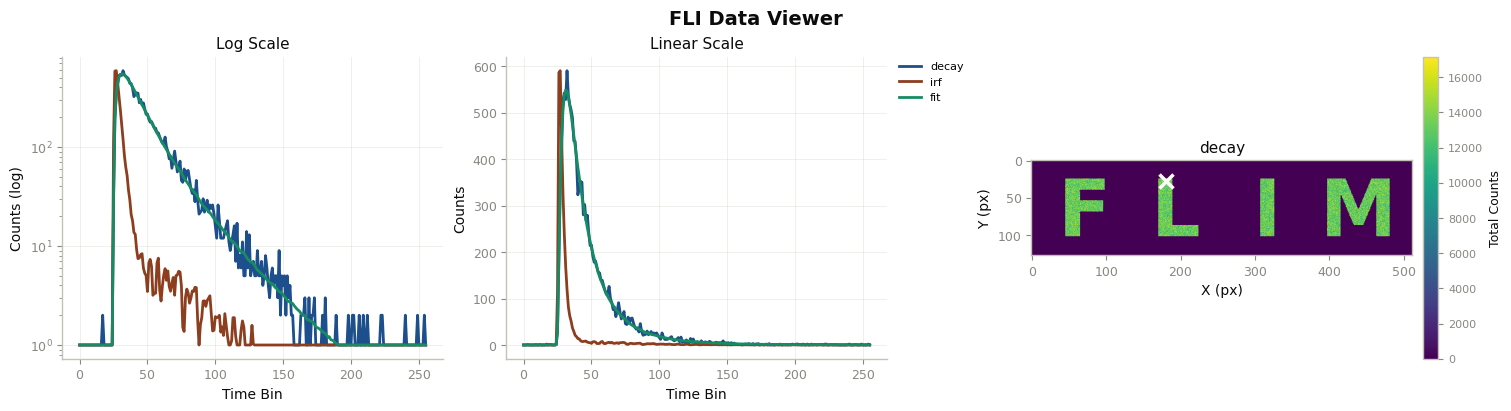

INFO:pyfli:
  Pixel (28, 181)
  ─────────────────────
  A         760.3301
  α         —
  τ₁        0.7261
  τ₂        —
  R²        0.9960
  Red.χ²    0.8621
  Raw.χ²    217.2543
  v-shift   0.0000
  h-shift   -0.1200
  ─────────────────────



--- MLE ---


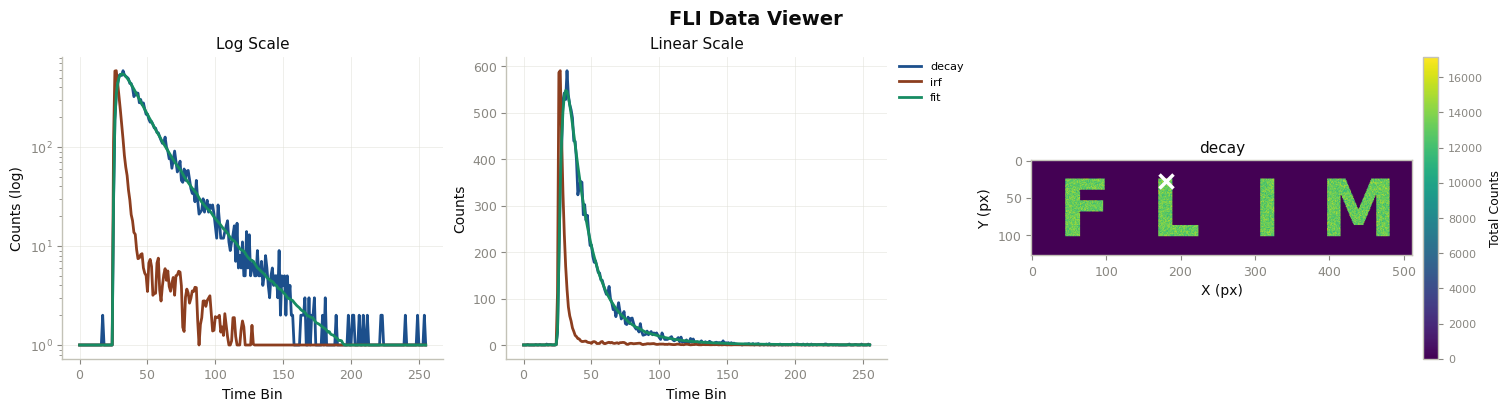

INFO:pyfli:
  Pixel (28, 181)
  ─────────────────────
  A         641.5303
  α         —
  τ₁        0.7367
  τ₂        —
  R²        0.9961
  Red.χ²    0.8150
  Raw.χ²    205.3772
  v-shift   0.1248
  h-shift   0.0115
  ─────────────────────



In [64]:
print(f"the non-zero pixel selected for probing is ({x}, {y})")
irf_norm = Normalization(_irf).norm_scale(_decay)
for name, maps, TRs in zip(experiments, all_datasets, all_fitset):
    print(f"--- {name} ---")
    DataViewer().plot_fli_px(
        data_list=[_decay, irf_norm, TRs["fit_map"], TRs["residual_map"]],
        pixel=(x, y),
        mode=[0, 1, 2],
        mode2=[0],
        names=["decay", "irf", "fit"],
    )
    _ = MessageDisplay().get_pixel_summary(data_maps=maps, px=(x, y))

## Summary

- **NLSF** (`BaseFLIFitter`, `"least_squares"`) is the faster option and a good default for pixels with high photon counts.
- **MLE** (`MLEFLIFitter`, `"poisson"`) models photon-counting noise directly and is preferred at low photon counts, at the cost of longer fitting time.
- Both return results with the same structure, so the maps, distributions and pixel diagnostics above can be produced for either estimator, or for any other fitter in `pyfli.solver`.